# RNN Training

In [23]:
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, SimpleRNN, Reshape, Concatenate
from tensorflow.keras.optimizers import Adam
import sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..', '..')))
from src.captioning.common.preprocessing import Tokenizer
from src.captioning.rnn.model import RNNCaptioner

In [24]:
data_dir = "../../../data/flickr8k"
features = np.load(os.path.join(data_dir, "features.npy"))
with open(os.path.join(data_dir, "features_index.json"), 'r') as f:
    features_index = json.load(f)
tokenizer = Tokenizer.load(os.path.join(data_dir, "tokenizer.json"))
with open(os.path.join(data_dir, "splits.json"), 'r') as f:
    splits = json.load(f)

def load_captions(file_path, tokenizer):
    with open(file_path, 'r') as f: lines = f.readlines()[1:]
    mapping = {}
    for line in lines:
        parts = line.split(',', 1)
        if len(parts) < 2: continue
        img_id, cap = parts[0], parts[1].strip()
        if img_id not in mapping: mapping[img_id] = []
        mapping[img_id].append(tokenizer.clean_caption(cap))
    return mapping
captions_mapping = load_captions(os.path.join(data_dir, "captions.txt"), tokenizer)

In [ ]:
def data_generator(image_ids, mapping, features, features_index, tokenizer, batch_size=32):
    X1, X2, y = [], [], []
    pad_val = tokenizer.word_index[tokenizer.pad_token]
    for img_id in image_ids:
        if img_id not in mapping or img_id not in features_index: continue
        img_feature = features[features_index[img_id]]
        for caption in mapping[img_id]:
            seq = [tokenizer.word_index[word] for word in caption.split() if word in tokenizer.word_index]
            # Pad to exactly max_length
            seq_padded = np.pad(seq, (0, max(0, tokenizer.max_length - len(seq))), 'constant', constant_values=pad_val)[:tokenizer.max_length]
            y_seq = np.append(seq_padded, pad_val)
            
            X1.append(img_feature)
            X2.append(seq_padded)
            y.append(y_seq)
            
            if len(X1) == batch_size:
                yield (np.array(X1), np.array(X2)), np.array(y)
                X1, X2, y = [], [], []

In [ ]:
def define_keras_model(vocab_size, max_length, embed_dim, hidden_dim, num_layers=1):
    inputs1 = Input(shape=(2048,))
    fe1 = Dense(embed_dim, activation='relu', name='image_projection')(inputs1)
    fe1_reshaped = Reshape((1, embed_dim))(fe1)
    
    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, embed_dim, mask_zero=True, name='embedding')(inputs2)
    
    # Pre-inject: Feature vector CNN di-concatenate di depan sequence embedding sebagai x_{-1}
    sequence_input = Concatenate(axis=1)([fe1_reshaped, se1])
    
    x = sequence_input
    for i in range(num_layers):
        x = SimpleRNN(hidden_dim, return_sequences=True, name=f'simple_rnn_{i}')(x)
        
    outputs = Dense(vocab_size, activation='softmax', name='dense_output')(x)
    
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001))
    return model

In [ ]:
configs = [
    {"name": "rnn_1layer_128", "layers": 1, "hidden_dim": 128, "embed_dim": 256},
    {"name": "rnn_1layer_512", "layers": 1, "hidden_dim": 512, "embed_dim": 256},
    {"name": "rnn_2layer_128", "layers": 2, "hidden_dim": 128, "embed_dim": 256},
    {"name": "rnn_2layer_512", "layers": 2, "hidden_dim": 512, "embed_dim": 256},
    {"name": "rnn_3layer_128", "layers": 3, "hidden_dim": 128, "embed_dim": 256},
    {"name": "rnn_3layer_512", "layers": 3, "hidden_dim": 512, "embed_dim": 256},
]

epochs = 5
batch_size = 64
total_samples = sum(len(captions_mapping.get(i, [])) for i in splits['train'])
steps = total_samples // batch_size
print(f"Total training captions: {total_samples}, Steps per epoch: {steps}")

Total training captions: 30000, Steps per epoch: 468


In [ ]:
weights_dir = "../../../weights/captioning/rnn"
os.makedirs(weights_dir, exist_ok=True)
histories = {}

for config in configs:
    print(f"\n--- Training Variation: {config['name']} ---")
    model = define_keras_model(
        tokenizer.vocab_size, tokenizer.max_length, 
        config['embed_dim'], config['hidden_dim'], config['layers']
    )
    
    history = []
    for e in range(epochs):
        gen = data_generator(splits['train'], captions_mapping, features, features_index, tokenizer, batch_size)
        h = model.fit(gen, epochs=1, steps_per_epoch=steps, verbose=1)
        history.append(h.history['loss'][0])
        
    histories[config['name']] = history
    model.save_weights(os.path.join(weights_dir, f"{config['name']}.weights.h5"))


--- Training Variation: rnn_1layer_128 ---
468/468 ━━━━━━━━━━━━━━━━━━━━ 55s 115ms/step - loss: 4.2487
468/468 ━━━━━━━━━━━━━━━━━━━━ 63s 135ms/step - loss: 3.2682
468/468 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - loss: 3.0325
468/468 ━━━━━━━━━━━━━━━━━━━━ 80s 171ms/step - loss: 2.8910
468/468 ━━━━━━━━━━━━━━━━━━━━ 82s 176ms/step - loss: 2.7733

--- Training Variation: rnn_1layer_512 ---
468/468 ━━━━━━━━━━━━━━━━━━━━ 376s 801ms/step - loss: 3.7944
468/468 ━━━━━━━━━━━━━━━━━━━━ 376s 802ms/step - loss: 3.0744
468/468 ━━━━━━━━━━━━━━━━━━━━ 317s 677ms/step - loss: 2.8137
468/468 ━━━━━━━━━━━━━━━━━━━━ 286s 611ms/step - loss: 2.6245
468/468 ━━━━━━━━━━━━━━━━━━━━ 279s 597ms/step - loss: 2.4822

--- Training Variation: rnn_2layer_128 ---
468/468 ━━━━━━━━━━━━━━━━━━━━ 75s 158ms/step - loss: 4.2862
468/468 ━━━━━━━━━━━━━━━━━━━━ 74s 157ms/step - loss: 3.2968
468/468 ━━━━━━━━━━━━━━━━━━━━ 74s 159ms/step - loss: 3.0475
468/468 ━━━━━━━━━━━━━━━━━━━━ 74s 159ms/step - loss: 2.8965
468/468 ━━━━━━━━━━━━━━━━━━━━ 74s 158m

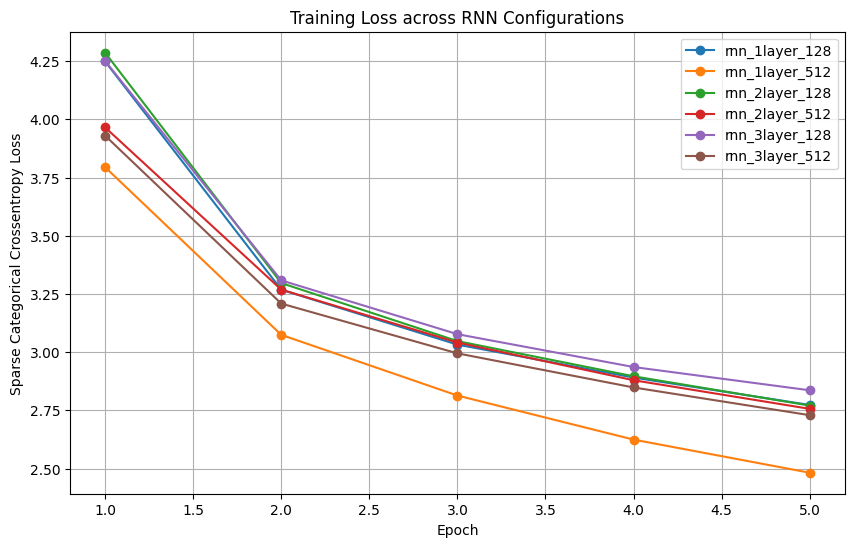

In [29]:
plt.figure(figsize=(10, 6))
for name, loss_hist in histories.items():
    plt.plot(range(1, epochs + 1), loss_hist, marker='o', label=name)
plt.title('Training Loss across RNN Configurations')
plt.xlabel('Epoch')
plt.ylabel('Sparse Categorical Crossentropy Loss')
plt.legend()
plt.grid(True)
plt.show()